WCZYTYWANIE DANYCH
===================

In [1]:
import numpy as np
print(np.__version__)

# NumPy 2.x compat: przywróć aliasy oczekiwane przez dask/lightgbm
if not hasattr(np, "round_"):
    np.round_ = np.round
if not hasattr(np, "unicode_"):
    np.unicode_ = np.str_

import warnings

warnings.filterwarnings(
    "ignore",
    message="A module that was compiled using NumPy 1.x"
)
warnings.filterwarnings(
    "ignore",
    message="Pandas requires version '1.3.6' or newer of 'bottleneck'"
)
from joblib import parallel_backend
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector, VarianceThreshold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, make_scorer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

ba_scorer = make_scorer(balanced_accuracy_score)


cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

1.26.4


In [13]:
scorer=[]
scorer_2=[]
scorer_2train=[]
params=[]

In [2]:
# wczytanie danych
cechy_train = pd.read_csv("artificial_train_data.csv")
etykiety_train = pd.read_csv("artificial_train_labels.csv")
cechy_test = pd.read_csv("artificial_test_data.csv")

# konwersja eoznaczen 1 na 1, 2 na 0 dla XGBoost
etykiety_train = etykiety_train.replace({2: 0})

X_train, X_test, y_train, y_test = train_test_split(cechy_train, etykiety_train, stratify=etykiety_train, test_size=0.15, random_state=42)

In [15]:
y_train = np.asarray(y_train).reshape(-1)
y_test  = np.asarray(y_test).reshape(-1)


WYBÓR SCALERA I K W SELECTKBEST
======================================================================

In [24]:

pipeline_stage1 = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(mutual_info_classif)), 
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# 1A - wybieram scaler i cechy
param_grid_stage1a = {
    'scaler': [StandardScaler(), RobustScaler(), None], # standadrdscaler=normalizacja, wrazliwy na outliery, robustscaler=odejmuje mediane i dzieli przez IQR, odporny na outliery
    'selector__k': [20, 30, 40, 50, 60],    # patrze ile cech oplaca sie wybrac tak aby usunac szum, ale zostawic potrzebne info        
    'classifier__n_estimators': [100],
    'classifier__learning_rate': [0.1],
    'classifier__max_depth': [5]
}

grid_stage1a = GridSearchCV(
    pipeline_stage1, 
    param_grid_stage1a, 
    cv=cv_strategy, 
    scoring=ba_scorer,
    n_jobs=-1,
    verbose=0
)

In [28]:
with parallel_backend("threading"):
    grid_stage1a.fit(X_train, y_train)

In [29]:
print(f"Najlepsze BA (Stage 1A): {grid_stage1a.best_score_:.4f}")
print(f"Najlepsze parametry: {grid_stage1a.best_params_}")
best_scaler = grid_stage1a.best_params_['scaler']
best_k = grid_stage1a.best_params_['selector__k']
print(f"Wybrany scaler: {best_scaler}, liczba cech: {best_k}")

Najlepsze BA (Stage 1A): 0.7867
Najlepsze parametry: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'scaler': RobustScaler(), 'selector__k': 40}
Wybrany scaler: RobustScaler(), liczba cech: 40


In [30]:
print(f"Wybrany scaler: {best_scaler}, liczba cech: {best_k}")

Wybrany scaler: RobustScaler(), liczba cech: 40


In [36]:
scorer.append({'Stage 1A': f"{grid_stage1a.best_score_:.5f}"})
params.append({'Stage 1A': grid_stage1a.best_params_})
scorer_2.append({'Stage 1A': f"{balanced_accuracy_score(y_test,grid_stage1a.predict(X_test)):.5f}"})
scorer_2train.append({'Stage 1A': f"{balanced_accuracy_score(y_train,grid_stage1a.predict(X_train)):.5f}"})


WSTEPNA OPTYMALIZACJA GRADIENT BOOSTING CLASSIFIER
======================================================================

In [31]:

# z pierwszej czesci zakładam RobustScaler() i k=40
pipeline_stage2 = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectKBest(mutual_info_classif, k=40)),  
    ('classifier', GradientBoostingClassifier(random_state=42))
])
# Wariant 2A: n_estimators, learning_rate, max_depth
param_grid_stage2a = {
    'classifier__n_estimators': [200, 300, 500], # ile drzew zbudowac
    'classifier__learning_rate': [0.01, 0.05, 0.1], # jak bardzo kolejne drzewo ma poprawiac poprzednie
    'classifier__max_depth': [3, 5, 7],  # jak glebokie drzewo
    'classifier__min_samples_split': [2],
    'classifier__subsample': [0.8] # na jakim fragmencie danych uczy sie kazde drzewo
}

grid_stage2a = GridSearchCV(
    pipeline_stage2, 
    param_grid_stage2a, 
    cv=cv_strategy, 
    scoring=ba_scorer,
    n_jobs=-1,
    verbose=1
)

In [ ]:
with parallel_backend("threading"):
    grid_stage2a.fit(X_train, y_train)


In [40]:
print(f"Najlepsze BA (Stage 2A): {grid_stage2a.best_score_:.4f}")
print(f"Najlepsze parametry: {grid_stage2a.best_params_}")
print(f"BA test: {balanced_accuracy_score(y_test,grid_stage2a.predict(X_test)):.5f}")
print(f"BA train: {balanced_accuracy_score(y_train,grid_stage2a.predict(X_train)):.5f}")


Najlepsze BA (Stage 2A): 0.8047
Najlepsze parametry: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 7, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500, 'classifier__subsample': 0.8}
BA test: 0.72487
BA train: 1.00000


In [116]:
def scoring_v2(grid_stage2a, stage_str):
    ba_scorer=make_scorer(balanced_accuracy_score)
    print(f"BA test: {balanced_accuracy_score(y_test,grid_stage2a.predict(X_test)):.5f}")
    print(f"BA train: {balanced_accuracy_score(y_train,grid_stage2a.predict(X_train)):.5f}")
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores=cross_val_score(grid_stage2a, X_train, y_train, cv=cv_strategy, scoring=ba_scorer, n_jobs=-1)
    print(f"CV mean: {np.mean(cv_scores):.5f}")
    print(f"CV std: {np.std(cv_scores):.5f}")
    if hasattr(grid_stage2a, 'best_score_'):
        print(f"Najlepsze BA: {grid_stage2a.best_score_:.4f}")
        print(f"Najlepsze parametry: {grid_stage2a.best_params_}")
        scorer.append({f'Stage {str(stage_str)}': f"{grid_stage2a.best_score_:.5f}"})
        params.append({f'Stage {str(stage_str)}': grid_stage2a.best_params_})   
    scorer_2.append({f'Stage {str(stage_str)}': f"{balanced_accuracy_score(y_test,grid_stage2a.predict(X_test)):.5f}"})
    scorer_2train.append({f'Stage {str(stage_str)}': f"{balanced_accuracy_score(y_train,grid_stage2a.predict(X_train)):.5f}"})

In [41]:
param_grid_stage2b = {
    'classifier__n_estimators': [300],  # nie wezmę 500 bo będzie overfitting
    'classifier__learning_rate': [0.01],  # <- z 2A
    'classifier__max_depth': [7],  # <- z 2A
    'classifier__min_samples_split': [2], # <- z 2A
    'classifier__min_samples_leaf': [1, 2, 4], # ilosc probek potrzebna do podzialu
    'classifier__subsample': [0.8] 
}

grid_stage2b = GridSearchCV(
    pipeline_stage2, 
    param_grid_stage2b, 
    cv=cv_strategy, 
    scoring=ba_scorer,
    n_jobs=-1,
    verbose=1
)



In [43]:
with parallel_backend("threading"):
    grid_stage2b.fit(X_train, y_train)
    
scoring_v2(grid_stage2b)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Najlepsze BA (Stage 2A): 0.7977
Najlepsze parametry: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
BA test: 0.82266
BA train: 1.00000


Wnioski: BA test się polepsza, ale mam przeuczenie.


PRÓBA SMOTE
======================================================================

In [45]:

pipeline_stage5 = ImbPipeline([
    ('scaler', RobustScaler()),
    ('selector', SelectKBest(mutual_info_classif, k=40)),
    ('smote', SMOTE(random_state=42)), # syntetyczne probki dla klasy mniejszosciowej, tworzenie nowych probek aby uczyc sie rownomiernie w klasach, dziala tylko na treningowym
    ('classifier', GradientBoostingClassifier(random_state=42))
])

param_grid_stage5 = {
    'smote': [SMOTE(random_state=42), SMOTETomek(random_state=42), None], # SMOTETomek czyli polaczenie oversamplingu i undersamplingu (usuwanie niepewnych probek klasy wikeszosciowej)
    'classifier__n_estimators': [300, 500],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [5, 7]
}

grid_stage5 = GridSearchCV(
    pipeline_stage5, 
    param_grid_stage5, 
    cv=cv_strategy, 
    scoring=ba_scorer,
    n_jobs=-1,
    verbose=1
)


In [ ]:
with parallel_backend("threading"):
    grid_stage5.fit(X_train, y_train)
    

In [49]:
scoring_v2(grid_stage5,5)

Najlepsze BA: 0.8235
Najlepsze parametry: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__n_estimators': 500, 'smote': None}
BA test: 0.72914
BA train: 1.00000


Wniosek: SMOTE nie pomoze.


SPRAWDZAM SELEKCJE CECH
======================================================================

In [52]:

from sklearn.feature_selection import VarianceThreshold, SelectFromModel

# Wariant 7A: RFE z Gradient Boosting
pipeline_stage7a = Pipeline([
    ('scaler', RobustScaler()),
    ('variance', VarianceThreshold(threshold=0.01)),  # usuń cechy z małą wariancją
    ('selector', RFE(GradientBoostingClassifier(random_state=42), n_features_to_select=30)), # rekurencyjne usuwanie cech, wybor najlepszych cech dla modelu
    ('classifier', GradientBoostingClassifier(random_state=42))
])

param_grid_stage7a = {
    'selector__n_features_to_select': [25, 30, 35, 40], # powtarza proces az zostanie okreslona liczba cech
    'classifier__n_estimators': [200, 300, 400],
    'classifier__learning_rate': [0.03, 0.05, 0.07],
    'classifier__max_depth': [4, 5, 6]
}

# rozbijam na częśći, bo jest za duo parametrów do sprawdzenia na raz

param_grid_stage7a_split1 = {
    'selector__n_features_to_select': [25, 30, 35, 40],
    'classifier__n_estimators': [200, 300, 400],
    'classifier__learning_rate': [0.05],
    'classifier__max_depth': [5]
}


grid_stage7a1 = GridSearchCV(
    pipeline_stage7a, 
    param_grid_stage7a_split1, 
    cv=cv_strategy, 
    scoring=ba_scorer,
    n_jobs=-1,
    verbose=0
)

In [53]:
with parallel_backend("threading"):
    grid_stage7a1.fit(X_train, y_train)
scoring_v2(grid_stage7a1,"7a_1")

Najlepsze BA: 0.8110
Najlepsze parametry: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 400, 'selector__n_features_to_select': 25}
BA test: 0.80465
BA train: 1.00000


In [54]:
param_grid_stage7a_split2 = {
    'selector__n_features_to_select': [25],  # z poprzedniego
    'classifier__n_estimators': [400],  # z poprzedniego
    'classifier__learning_rate': [0.03, 0.07],
    'classifier__max_depth': [4, 5, 7]
}
grid_stage7a2 = GridSearchCV(
    pipeline_stage7a, 
    param_grid_stage7a_split2, 
    cv=cv_strategy, 
    scoring=ba_scorer,
    n_jobs=-1,
    verbose=1
)


In [55]:
with parallel_backend("threading"):
    grid_stage7a2.fit(X_train, y_train)
scoring_v2(grid_stage7a2,"7a_2")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Najlepsze BA: 0.8306
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 7, 'classifier__n_estimators': 400, 'selector__n_features_to_select': 25}
BA test: 0.82243
BA train: 1.00000


In [69]:
# 7B: Sprawdzam SelectFromModel 
pipeline_stage7b = Pipeline([
    ('scaler', RobustScaler()),
    ('selector', SelectFromModel(                   
        GradientBoostingClassifier(n_estimators=100, random_state=42),
        threshold='median'                   # czyli, zachowaj najwazniejsze cechy wzgledem mediany wedlug ich przydatnosci w GBC   
    )),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

param_grid_stage7b_split1 = {
    'selector__threshold': ['mean', 'median', '0.5*mean', '1.25*mean'], # czym ma sie sugerowac selector
    'classifier__n_estimators': [400],
    'classifier__learning_rate': [0.07],
    'classifier__max_depth': [5] # nie zrobię 7, bo to nie polepszy sytuacji z overfittingiem
}

grid_stage7b1 = GridSearchCV(
    pipeline_stage7b, 
    param_grid_stage7b_split1, 
    cv=cv_strategy, 
    scoring=ba_scorer,
    n_jobs=-1,
    verbose=1
)


In [70]:
with parallel_backend("threading"):
    grid_stage7b1.fit(X_train, y_train)
scoring_v2(grid_stage7b1,"7b_1")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Najlepsze BA: 0.8212
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 5, 'classifier__n_estimators': 400, 'selector__threshold': '1.25*mean'}
BA test: 0.82266
BA train: 1.00000


VOTING(XGB,GB,RF)
================

In [180]:
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier

pipeline_stage6 = Pipeline([
        ('scaler', RobustScaler()),
        ('selector', SelectKBest(mutual_info_classif, k=40)),
        ('classifier', VotingClassifier(
            estimators=[
                ('gb', GradientBoostingClassifier(
                    n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
                )),
                ('xgb', XGBClassifier(
                    n_estimators=300, learning_rate=0.05, max_depth=5, 
                    random_state=42, eval_metric='logloss'
                )),
                ('rf', RandomForestClassifier(              # rozni sie od gradient boostingu tym, ze drzewa sa od siebie niezalezne i kazde drzewo dostaje losowe dane
                    n_estimators=300, max_depth=10, random_state=42
                )),
            ],
            voting='soft'
        ))
    ])
pipeline_stage6.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function mut...t 0x179f7b380>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",40


In [181]:
vot=cross_val_score(pipeline_stage6, X_train, y_train, 
                           cv=cv_strategy, scoring=ba_scorer, n_jobs=-1)

/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

In [194]:
print(f"{vot},\n mean: {vot.mean()}, \n std: {vot.std()}, \n BA test:{balanced_accuracy_score(y_test,pipeline_stage6.predict(X_test)):.5f},\n BA train:{balanced_accuracy_score(y_train,pipeline_stage6.predict(X_train)):.5f},")

[0.75775194 0.7377261  0.76870079 0.80016609 0.72173351],
 mean: 0.7572156859752998, 
 std: 0.026891489802690943, 
 BA test:0.73329,
 BA train:1.00000,


GB FINE  TUNING
===========

Teraz zrobię finee tuning wokół 1.25*mean

In [ ]:

pipeline_17 = Pipeline([
    ('scaler', RobustScaler()),
    ('selector', SelectFromModel(
        GradientBoostingClassifier(n_estimators=100, random_state=42), # dalo dobre wyniki w 7 etapie
        threshold='1.25*mean'
    )),
    ('classifier', GradientBoostingClassifier(random_state=42)) # do tej pory GBC sie dobrze sprawowal
])

# 17A: w okolicy 1.25*mean
param_grid_17a_1 = {
    'selector__estimator__n_estimators': [90],
    'selector__threshold': ['1.1*mean', '1.15*mean', '1.2*mean', '1.25*mean', '1.3*mean'],
    'classifier__n_estimators': [500],           # biorę 500, bo wyszło tak najlepiej w 7B
    'classifier__learning_rate': [0.07],
    'classifier__max_depth': [6]
}



grid_17a_1 = GridSearchCV(pipeline_17, param_grid_17a_1, cv=cv_strategy, 
                        scoring=ba_scorer, n_jobs=-1, verbose=1)




[ETAP 17] Micro-tuning wokół najlepszych parametrów
--------------------------------------------------------------------------------


In [73]:
with parallel_backend("threading"):
    grid_17a_1.fit(X_train, y_train)
scoring_v2(grid_17a_1,"17a_1")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najlepsze BA: 0.8392
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 6, 'classifier__n_estimators': 500, 'selector__estimator__n_estimators': 90, 'selector__threshold': '1.2*mean'}
BA test: 0.82717
BA train: 1.00000


In [75]:
param_grid_17a_2 = {
    'selector__estimator__n_estimators': [90, 100, 110],
    'selector__threshold': ['1.2*mean'], 
    'classifier__n_estimators': [500],
    'classifier__learning_rate': [0.07],
    'classifier__max_depth': [6]
}
grid_17a_2 = GridSearchCV(pipeline_17, param_grid_17a_2, cv=cv_strategy, 
                        scoring=ba_scorer, n_jobs=-1, verbose=1)

In [76]:
with parallel_backend("threading"):
    grid_17a_2.fit(X_train, y_train)
scoring_v2(grid_17a_2,"17a_2")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Najlepsze BA: 0.8408
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 6, 'classifier__n_estimators': 500, 'selector__estimator__n_estimators': 100, 'selector__threshold': '1.2*mean'}
BA test: 0.82243
BA train: 1.00000


In [77]:
# 17B: Learning rate wokół 0.07
param_grid_17b = {
    'selector__estimator__n_estimators': [100],
    'selector__threshold': ['1.2*mean'],
    'classifier__n_estimators': [500],
    'classifier__learning_rate': [0.06, 0.065, 0.07, 0.075, 0.08],
    'classifier__max_depth': [6]
}

grid_17b = GridSearchCV(pipeline_17, param_grid_17b, cv=cv_strategy, 
                        scoring=ba_scorer, n_jobs=-1, verbose=1)

In [78]:
with parallel_backend("threading"):
    grid_17b.fit(X_train, y_train)
scoring_v2(grid_17b,"17b")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najlepsze BA: 0.8408
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 6, 'classifier__n_estimators': 500, 'selector__estimator__n_estimators': 100, 'selector__threshold': '1.2*mean'}
BA test: 0.82243
BA train: 1.00000


In [85]:
# 17C: N_estimators wokół 500
param_grid_17c = {
    'selector__estimator__n_estimators': [100],
    'selector__threshold': ['1.2*mean'],
    'classifier__n_estimators': [450, 475, 500, 525, 550, 575, 600],
    'classifier__learning_rate': [0.07],  # najlepszy z 17B
    'classifier__max_depth': [6]
}

grid_17c = GridSearchCV(pipeline_17, param_grid_17c, cv=cv_strategy, 
                        scoring=ba_scorer, n_jobs=-1, verbose=1)


In [86]:
with parallel_backend("threading"):
    grid_17c.fit(X_train, y_train)
scoring_v2(grid_17c,"17c")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Najlepsze BA: 0.8416
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 6, 'classifier__n_estimators': 600, 'selector__estimator__n_estimators': 90, 'selector__threshold': '1.2*mean'}
BA test: 0.82266
BA train: 1.00000


In [87]:
# 17D: Max_depth wokół 6
param_grid_17d = {
    'selector__estimator__n_estimators': [100],
    'selector__threshold': ['1.2*mean'],
    'classifier__n_estimators': [600],  # najlepszy z 17C
    'classifier__learning_rate': [0.07],
    'classifier__max_depth': [5, 6, 7, 8]
}
grid_17d = GridSearchCV(pipeline_17, param_grid_17d, cv=cv_strategy, 
                        scoring=ba_scorer, n_jobs=-1, verbose=1)

In [88]:
with parallel_backend("threading"):
    grid_17d.fit(X_train, y_train)
scoring_v2(grid_17d,"17d")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Najlepsze BA: 0.8416
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 6, 'classifier__n_estimators': 600, 'selector__estimator__n_estimators': 90, 'selector__threshold': '1.2*mean'}
BA test: 0.82266
BA train: 1.00000


In [89]:
# 17E: Regularyzacja
param_grid_17e_1 = {
    'selector__estimator__n_estimators': [100],
    'selector__threshold': ['1.2*mean'],
    'classifier__n_estimators': [600],
    'classifier__learning_rate': [0.07],
    'classifier__max_depth': [6],  
    'classifier__min_samples_split': [2, 3, 4, 5],
    'classifier__min_samples_leaf': [1, 2]
}
grid_17e_1 = GridSearchCV(pipeline_17, param_grid_17e_1, cv=cv_strategy, 
                        scoring=ba_scorer, n_jobs=-1, verbose=1)

In [90]:
with parallel_backend("threading"):
    grid_17e_1.fit(X_train, y_train)
scoring_v2(grid_17e_1,"17e_1")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Najlepsze BA: 0.8431
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 6, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 600, 'selector__estimator__n_estimators': 100, 'selector__threshold': '1.2*mean'}
BA test: 0.82243
BA train: 1.00000


In [91]:
param_grid_17e_2 = {
    'selector__estimator__n_estimators': [100],
    'selector__threshold': ['1.2*mean'], 
    'classifier__n_estimators': [600], 
    'classifier__learning_rate': [0.07], 
    'classifier__max_depth': [6],  
    'classifier__min_samples_split': [5],
    'classifier__min_samples_leaf': [1, 3], 
    'classifier__subsample': [0.75, 0.8, 0.85, 0.9]
}

grid_17e_2 = GridSearchCV(pipeline_17, param_grid_17e_2, cv=cv_strategy, 
                        scoring=ba_scorer, n_jobs=-1, verbose=1)

In [92]:
with parallel_backend("threading"):
    grid_17e_2.fit(X_train, y_train)
scoring_v2(grid_17e_2,"17e_2")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Najlepsze BA: 0.8439
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 6, 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 600, 'classifier__subsample': 0.8, 'selector__estimator__n_estimators': 100, 'selector__threshold': '1.2*mean'}
BA test: 0.83132
BA train: 1.00000


In [93]:
# 17F: Max_features
param_grid_17f = {
    'selector__estimator__n_estimators': [100],
    'selector__threshold': ['1.2*mean'],
    'classifier__n_estimators': [600],
    'classifier__learning_rate': [0.07],
    'classifier__max_depth': [6],
    'classifier__min_samples_split': [5],  
    'classifier__min_samples_leaf': [1],   
    'classifier__subsample': [0.8],        
    'classifier__max_features': ['sqrt', 'log2', 0.4, 0.5, 0.6, 0.7, 0.8, None] # 0.6 najlepsze
}
grid_17f = GridSearchCV(pipeline_17, param_grid_17f, cv=cv_strategy, 
                        scoring=ba_scorer, n_jobs=-1, verbose=1)

In [94]:
with parallel_backend("threading"):
    grid_17f.fit(X_train, y_train)
scoring_v2(grid_17f,"17f")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Najlepsze BA: 0.8447
Najlepsze parametry: {'classifier__learning_rate': 0.07, 'classifier__max_depth': 6, 'classifier__max_features': 0.6, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 600, 'classifier__subsample': 0.8, 'selector__estimator__n_estimators': 100, 'selector__threshold': '1.2*mean'}
BA test: 0.80453
BA train: 1.00000


NAJLEPSZY GRADIENTBOOSTING WZGLEDEM GRIDSEARCH
==================

In [185]:
# najlepszy pipeline wzgędem gridsearchl
pipeline_17f = Pipeline([
    ('scaler', RobustScaler()),
    ('selector', SelectFromModel(
        estimator=GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ),
        threshold='1.2*mean'
    )),
    ('classifier', GradientBoostingClassifier(
        n_estimators=600,
        learning_rate=0.07,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=1,
        subsample=0.8,
        random_state=42
    ))
])

In [186]:
with parallel_backend("threading"):
    pipeline_17f.fit(X_train, y_train) 
scoring_v2(pipeline_17f,"Najlepszy GB")

BA test: 0.82641
BA train: 1.00000


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

CV mean: 0.83840
CV std: 0.01598


In [187]:
pipeline_17f.get_params()

{'memory': None,
 'steps': [('scaler', RobustScaler()),
  ('selector',
   SelectFromModel(estimator=GradientBoostingClassifier(random_state=42),
                   threshold='1.2*mean')),
  ('classifier',
   GradientBoostingClassifier(learning_rate=0.07, max_depth=6, min_samples_split=5,
                              n_estimators=600, random_state=42, subsample=0.8))],
 'transform_input': None,
 'verbose': False,
 'scaler': RobustScaler(),
 'selector': SelectFromModel(estimator=GradientBoostingClassifier(random_state=42),
                 threshold='1.2*mean'),
 'classifier': GradientBoostingClassifier(learning_rate=0.07, max_depth=6, min_samples_split=5,
                            n_estimators=600, random_state=42, subsample=0.8),
 'scaler__copy': True,
 'scaler__quantile_range': (25.0, 75.0),
 'scaler__unit_variance': False,
 'scaler__with_centering': True,
 'scaler__with_scaling': True,
 'selector__estimator__ccp_alpha': 0.0,
 'selector__estimator__criterion': 'friedman_mse',
 'sel


PROBA HistGradientBoosting (najszybszy, często lepszy)
======================================================================

In [ ]:


from sklearn.ensemble import HistGradientBoostingClassifier

pipeline_stage9 = Pipeline([
    ('scaler', RobustScaler()),
    ('selector', SelectKBest(mutual_info_classif, k=40)),
    ('classifier', HistGradientBoostingClassifier(random_state=42)) # przydatny przy duzych zbiorach danych bo grupuje wartosci, tu sie nie sprawdza
])

param_grid_stage9a = {
    'selector__k': [35, 40, 45, 50],
    'classifier__max_iter': [200, 300, 400],
    'classifier__learning_rate': [0.05, 0.1, 0.15],
    'classifier__max_depth': [None, 5, 7, 10]
}
# rozbijam na części

param_grid_stage9a_split1 = {
    'selector__k': [35, 43, 50],
    'classifier__max_iter': [200, 300, 400],
    'classifier__learning_rate': [0.1],
    'classifier__max_depth': [None]
}


param_grid_stage9a_split2 = {
    'selector__k': [50], # z poprzedniego
    'classifier__max_iter': [300],  # z poprzedniego
    'classifier__learning_rate': [0.05, 0.1, 0.15],
    'classifier__max_depth': [None, 5, 9]
}

param_grid_stage9a_split3 = {
    'selector__k': [40],
    'classifier__max_iter': [300],
    'classifier__learning_rate': [0.15],  # z poprzedniego
    'classifier__max_depth': [None],  # z poprzedniego
    'classifier__min_samples_leaf': [10, 20, 30, 40],
    'classifier__max_leaf_nodes': [15, 31, 50, None]
}


grid_stage9a1 = GridSearchCV(pipeline_stage9, param_grid_stage9a_split1, 
                             cv=cv_strategy, scoring=ba_scorer, n_jobs=-1, verbose=1)
grid_stage9a2 = GridSearchCV(pipeline_stage9, param_grid_stage9a_split2, 
                             cv=cv_strategy, scoring=ba_scorer, n_jobs=-1, verbose=1)
grid_stage9a3 = GridSearchCV(pipeline_stage9, param_grid_stage9a_split3, 
                             cv=cv_strategy, scoring=ba_scorer, n_jobs=-1, verbose=1)



In [ ]:
grid_stage9a1.fit(X_train, y_train)
print(f"Najlepsze BA (Stage 9A1): {grid_stage9a1.best_score_:.4f}")
print(f"Najlepsze parametry: {grid_stage9a1.best_params_}")


In [ ]:
grid_stage9a2.fit(X_train, y_train)
print(f"Najlepsze BA (Stage 9A2): {grid_stage9a2.best_score_:.4f}")
print(f"Najlepsze parametry: {grid_stage9a2.best_params_}")


In [193]:
with parallel_backend("threading"):
    grid_stage9a3.fit(X_train, y_train)
scoring_v2(grid_stage9a3,"9a3")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
BA test: 0.73779
BA train: 1.00000


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
CV mean: 0.75148
CV std: 0.03099
Najlepsze BA: 0.7727
Najlepsze parametry: {'classifier__learning_rate': 0.15, 'classifier__max_depth': None, 'classifier__max_iter': 300, 'classifier__max_leaf_nodes': 50, 'classifier__min_samples_leaf': 10, 'selector__k': 40}



VOTING Z NAJLEPSZYM GRADIENT BOOSTING Z ROZNYMI SEED
======================================================================

In [ ]:
from sklearn.ensemble import VotingClassifier

def create_optimized_pipeline(seed):
    """Tworzy pipeline z optymalnymi parametrami i danym seedem"""
    return Pipeline([
        ('scaler', RobustScaler()),
        ('selector', SelectFromModel(
            GradientBoostingClassifier(n_estimators=100, random_state=seed),
            threshold='1.2*mean'
        )),
        ('classifier', GradientBoostingClassifier(
            n_estimators=600,
            learning_rate=0.07,
            max_depth=6,
            subsample=0.8,
            min_samples_split=5,
            min_samples_leaf=1,
            random_state=seed
        ))
    ])

pipeline_33 = Pipeline([
    ('scaler', RobustScaler()),
    ('ensemble', VotingClassifier(
        estimators=[
            ('model1', create_optimized_pipeline(42)),
            ('model2', create_optimized_pipeline(123)),
            ('model3', create_optimized_pipeline(456)),
        ],
        voting='soft'
    ))
])

In [190]:
pipeline_33.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ensemble', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False
,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('model1', ...), ('model2', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'


In [191]:
scoring_v2(pipeline_33,"33")

BA test: 0.83530
BA train: 1.00000


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

CV mean: 0.84706
CV std: 0.01399



ZOBACZMY TERAZ ULEPSZONY GRADIENT BOOSTING - LGBM I XGB
======================================================================

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, balanced_accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

pipeline_xgb = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=500,       # obnizam by uniknac overfittingu
            learning_rate=0.07,
            max_depth=6,
            subsample=0.8,
            min_samples_split=5,
            min_samples_leaf=3,    # podwyzszam by uniknac overfittingu
            random_state=42, max_features='sqrt'
        ),
        threshold='1.2*mean'
    )),
    ('classifier', XGBClassifier( eval_metric='logloss', 
            n_estimators=400,  # obnizam by uniknac overfittingu
            learning_rate=0.07,
            max_depth=6,
            subsample=0.8,
            random_state=42))
])

param_grid_xgb_1 = {
    'classifier__colsample_bytree': [0.8, 0.9, 1.0],
    'classifier__min_child_weight': [4, 3, 5],
    'classifier__reg_alpha': [0.5], # usuwa nieistotne cechy
    'classifier__reg_lambda': [1] # wygladza wagi, zmniejsza overfitting
}

grid_xgb_1 = GridSearchCV(
    pipeline_xgb,
    param_grid_xgb_1,
    cv=5,
    scoring=ba_scorer,
    verbose=0,
    n_jobs=-1,
    return_train_score=True
)





In [138]:
with parallel_backend("threading"):
    grid_xgb_1.fit(X_train, y_train)
scoring_v2(grid_xgb_1,"xgb_1")

Najlepsze BA: 0.8597
Najlepsze parametry: {'classifier__colsample_bytree': 0.8, 'classifier__min_child_weight': 3, 'classifier__reg_alpha': 0.5, 'classifier__reg_lambda': 1}
BA test: 0.80880
BA train: 0.99921


In [ ]:
pipeline_lgbm = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.07, # analogicznie
            max_depth=6,
            subsample=0.8,
            min_samples_split=5,
            min_samples_leaf=3, # analogicznie
            max_features='sqrt',
            random_state=42
        ),
        threshold='1.2*mean'
    )),
    ('classifier', LGBMClassifier(min_samples_split=5,
            min_samples_leaf=3,
            classifier__n_estimators=400,   # analogicznie
            classifier__learning_rate=0.06,
            classifier__max_depth=6,
            classifier__subsample=0.85,
            random_state=42, verbose=-1))
])

param_grid_lgbm = {
    'classifier__colsample_bytree': [0.9],
    'classifier__min_child_samples': [5, 10, 20],
    'classifier__num_leaves': [20,30,40]
}

grid_lgbm = GridSearchCV(
    pipeline_lgbm,
    param_grid_lgbm,
    cv=5,
    scoring=ba_scorer,
    verbose=0,
    n_jobs=-1,
    return_train_score=True
)



In [149]:
with parallel_backend("threading"):
    grid_lgbm.fit(X_train, y_train)
scoring_v2(grid_lgbm,"lgbm")

Najlepsze BA: 0.8706
Najlepsze parametry: {'classifier__colsample_bytree': 0.9, 'classifier__min_child_samples': 5, 'classifier__num_leaves': 40}
BA test: 0.82243
BA train: 1.00000


In [ ]:
param_grid_xgb_2 = {
    'classifier__colsample_bytree': [0.8], # z poprzedniego
    'classifier__min_child_weight': [3], # z poperzedniego
    'classifier__reg_alpha': [0, 0.1, 1], # usuwa nieistotne cechy, 0
    'classifier__reg_lambda': [1, 2] # wygladza wagi, zmniejsza overfitting, 1
}
grid_xgb_2 = GridSearchCV(
    pipeline_xgb,
    param_grid_xgb_2,
    cv=5,
    scoring=ba_scorer,
    verbose=0,
    n_jobs=-1,
    return_train_score=True
)


In [213]:
pipeline_lgbm = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.07, # analogicznie
            max_depth=6,
            subsample=0.8,
            min_samples_split=5,
            min_samples_leaf=3, # analogicznie
            max_features='sqrt',
            random_state=42
        ),
        threshold='1.2*mean'
    )),
    ('classifier', LGBMClassifier(
            colsample_bytree=0.9,
            num_leaves=40,
            min_child_samples=5,
            random_state=42, verbose=-1))
])

In [27]:
pipeline_xgb = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=500,       # obnizam by uniknac overfittingu
            learning_rate=0.07,
            max_depth=6,
            subsample=0.8,
            min_samples_split=5,
            min_samples_leaf=3,    # podwyzszam by uniknac overfittingu
            random_state=42, 
            max_features='sqrt'
        ),
        threshold='1.2*mean'
    )),
    ('classifier', XGBClassifier( eval_metric='logloss', 
            n_estimators=400,  # obnizam by uniknac overfittingu
            learning_rate=0.07,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            reg_alpha=0,
            reg_lambda=1,
            random_state=42))
])

METRYKI FUNKCJA
===========================

In [16]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, balanced_accuracy_score)
def metryki(pipeline, X_train, y_train, X_test, y_test):

    pipeline.fit(X_train, y_train)

    y_test_pred=pipeline.predict(X_test)
    y_train_pred=pipeline.predict(X_train)
    y_train_proba = pipeline.predict_proba(X_train)[:, 1]
    y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    train_metrics = {
        'Balanced Accuracy': balanced_accuracy_score(y_train, y_train_pred),
        'Accuracy': accuracy_score(y_train, y_train_pred),
        'Precision': precision_score(y_train, y_train_pred),
        'Recall': recall_score(y_train, y_train_pred),
        'F1 Score': f1_score(y_train, y_train_pred),
        'ROC AUC': roc_auc_score(y_train, y_train_proba)
    }
    test_metrics = {
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_test_pred),
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1 Score': f1_score(y_test, y_test_pred),
        'ROC AUC': roc_auc_score(y_test, y_test_proba)
    }
    cv=cross_val_score(pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy', n_jobs=-1)

    print()
    return train_metrics, test_metrics, {'CV Balanced Accuracy Mean': float(cv.mean()), 'CV Balanced Accuracy Std': float(cv.std())}

In [17]:
from sklearn.model_selection import cross_val_score
from joblib import parallel_backend

# Helper: licz metryki bez nadpisywania funkcji nazwą słownika
def metryki_testsize(pipeline, test_size, cv=cv_strategy):
    X_tr, X_te, y_tr, y_te = train_test_split(
        cechy_train, etykiety_train,
        test_size=test_size, random_state=42, stratify=etykiety_train
    )
    with parallel_backend("threading", n_jobs=-1):
        pipeline.fit(X_tr, y_tr)
    y_tr_pred = pipeline.predict(X_tr)
    y_te_pred = pipeline.predict(X_te)
    ba_tr = balanced_accuracy_score(y_tr, y_tr_pred)
    ba_te = balanced_accuracy_score(y_te, y_te_pred)
    cv_scores = cross_val_score(
        pipeline, X_tr, y_tr,
        cv=cv, scoring=ba_scorer, n_jobs=-1
    )
    return {
        str(test_size): {
            'train': {'Balanced Accuracy': ba_tr},
            'test': {'Balanced Accuracy': ba_te},
            'cv': {
                'CV Balanced Accuracy Mean': float(np.mean(cv_scores)),
                'CV Balanced Accuracy Std': float(np.std(cv_scores))
            }
        }
    }


In [18]:
def metryki_dla_roznych_test_size(pipeline, test_sizes):
    """
    Oblicza metryki dla różnych wartości test_size.
    
    Args:
        pipeline: Model do trenowania
        test_sizes: Lista wartości test_size do przetestowania (np. [0.1, 0.2, 0.3])
    
    Returns:
        Słownik z wynikami dla każdego test_size
    """
    wyniki = []
    for test_size in test_sizes:
        wyniki.append(metryki_testsize(pipeline, test_size))
    return wyniki


WYKRESY
======================================================================

In [199]:
import matplotlib.pyplot as plt
test_sizes = sorted([0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], reverse=True)



def wykres_w_zal_od_ts(test_sizes,pipeline,title):
    wszystkie_wyniki = metryki_dla_roznych_test_size(pipeline, test_sizes)
    test_sizes_lista = []
    balanced_acc_test = []
    balanced_acc_train = []
    balanced_acc_cv = []

    for wynik_dict in wszystkie_wyniki:
        for ts, metryki_dict in wynik_dict.items():
            test_sizes_lista.append(float(ts))
            balanced_acc_test.append(metryki_dict['test']['Balanced Accuracy'])
            balanced_acc_train.append(metryki_dict['train']['Balanced Accuracy'])
            balanced_acc_cv.append(metryki_dict['cv']['CV Balanced Accuracy Mean'])

    # Sortowanie według test_size (jeśli potrzebne)
    sorted_data = sorted(zip(test_sizes_lista, balanced_acc_test, balanced_acc_train, balanced_acc_cv))
    test_sizes_lista, balanced_acc_test, balanced_acc_train, balanced_acc_cv = zip(*sorted_data)

    plt.figure(figsize=(10, 6))
    plt.plot(test_sizes_lista, balanced_acc_test, marker='o', label='Test')
    plt.plot(test_sizes_lista, balanced_acc_train, marker='s', label='Train')
    plt.plot(test_sizes_lista, balanced_acc_cv, marker='^', label='CV')
    plt.xlabel('Test Size')
    plt.ylabel('Balanced Accuracy')
    plt.title(f'Wpływ test_size na BA {title}')
    plt.legend()
    plt.grid(True)
    plt.show()

FINE TUNING XGB
==========================

Chce zmniejszyć overfit na xgb.

In [ ]:
pipeline_xgb_balanced = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,       # obnizam z 500
            learning_rate=0.06,      # obnizam z 0.07
            max_depth=6,
            subsample=0.8,          
            min_samples_split=5,
            min_samples_leaf=3,    
            random_state=42, 
            max_features='sqrt'
        ),
        threshold='1.2*mean'
    )),
    ('classifier', XGBClassifier( eval_metric='logloss', 
            n_estimators=350,  # zmniejszam z 400
            learning_rate=0.06, # obnizam z 0.07
            max_depth=5,        # obnizam z 6
            subsample=0.8,      
            colsample_bytree=0.8,   # sprawdze sąsiednie wartosci
            min_child_weight=3,
            reg_alpha=0.1,         # powyzszam z 0
            reg_lambda=2,       # pdwyzszam z 1
            random_state=42))
])

In [65]:
with parallel_backend("threading"):
    pipeline_xgb_balanced.fit(X_train, y_train)
scoring_v2(pipeline_xgb_balanced, "xgb_balanced")

BA test: 0.81756
BA train: 0.99844


In [8]:
pipeline_xgb_balanced_2 = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,       
            learning_rate=0.06,      
            max_depth=6,
            subsample=0.8,          
            min_samples_split=5,
            min_samples_leaf=3,    
            random_state=42, 
            max_features='sqrt'
        ),
        threshold='1.2*mean'
    )),
    ('classifier', XGBClassifier( eval_metric='logloss', 
            n_estimators=300,  # zmniejszam z 350
            learning_rate=0.06, 
            max_depth=5,        
            subsample=0.8,      
            colsample_bytree=0.8,   
            min_child_weight=3,
            reg_alpha=0.2,         # podwyzszam z 0.1
            reg_lambda=4,       # pdwyzszam z 2
            random_state=42))])

In [67]:
with parallel_backend("threading"):
    pipeline_xgb_balanced_2.fit(X_train, y_train)
scoring_v2(pipeline_xgb_balanced_2, "xgb_balanced_2")

BA test: 0.82202
BA train: 0.99139


In [195]:
scoring_v2(pipeline_xgb_balanced_2, "xgb_balanced_2")

BA test: 0.82202
BA train: 0.99139


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

CV mean: 0.84791
CV std: 0.02545


Sprawdzę ile cech wybiera selektor.

In [68]:
n_cech = pipeline_xgb_balanced_2.named_steps['selector'].get_support().sum()
print(f"Liczba wybranych cech: {n_cech}")

Liczba wybranych cech: 22


In [5]:
pipeline_xgb_balanced_3 = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,       
            learning_rate=0.06,      
            max_depth=6,
            subsample=0.85,          # podwyzszam z 0.8         
            min_samples_split=5,
            min_samples_leaf=3,    
            random_state=42, 
            max_features='sqrt'
        ),
        threshold='1.2*mean'
    )),
    ('classifier', XGBClassifier( eval_metric='logloss', 
            n_estimators=320,  # podwyzszam lekko z 300
            learning_rate=0.06, 
            max_depth=5,        
            subsample=0.8,        
            colsample_bytree=0.8,   
            min_child_weight=3,
            reg_alpha=0.3,         # podwyzszam z 0.2
            reg_lambda=4,       
            random_state=42))])

In [72]:
with parallel_backend("threading"):
    pipeline_xgb_balanced_3.fit(X_train, y_train)
scoring_v2(pipeline_xgb_balanced_3, "xgb_balanced_3")

BA test: 0.84869
BA train: 0.98902


In [196]:
scoring_v2(pipeline_xgb_balanced_3, "xgb_balanced_3")

BA test: 0.84869
BA train: 0.98902


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


CV mean: 0.85970
CV std: 0.01612


In [73]:
n_cech = pipeline_xgb_balanced_3.named_steps['selector'].get_support().sum()
print(f"Liczba wybranych cech: {n_cech}")

Liczba wybranych cech: 19


In [4]:
pipeline_xgb_balanced_4 = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,       
            learning_rate=0.06,      
            max_depth=6,
            subsample=0.85,                  
            min_samples_split=5,
            min_samples_leaf=3,    
            random_state=42, 
            max_features='sqrt'
        ),
        threshold='1.2*mean'
    )),
    ('classifier', XGBClassifier( 
            eval_metric='logloss', 
            n_estimators=320,  
            learning_rate=0.06, 
            max_depth=5,        
            subsample=0.85,        # podwyzszam z 0.8
            colsample_bytree=0.85,   # podwyzszam z 0.8
            min_child_weight=3,
            reg_alpha=0.3,         
            reg_lambda=4,
            gamma=0.2,             # DODAJĘ mówię, ze podzial na drzewa musi dac poprawę lepszą  0.2, przeciwdziała overfittingowi       
            random_state=42))])

In [117]:
with parallel_backend("threading"):
    pipeline_xgb_balanced_4.fit(X_train, y_train)
scoring_v2(pipeline_xgb_balanced_4, "xgb_balanced_4")

BA test: 0.85758
BA train: 0.99060
CV mean: 0.85417
CV std: 0.00520


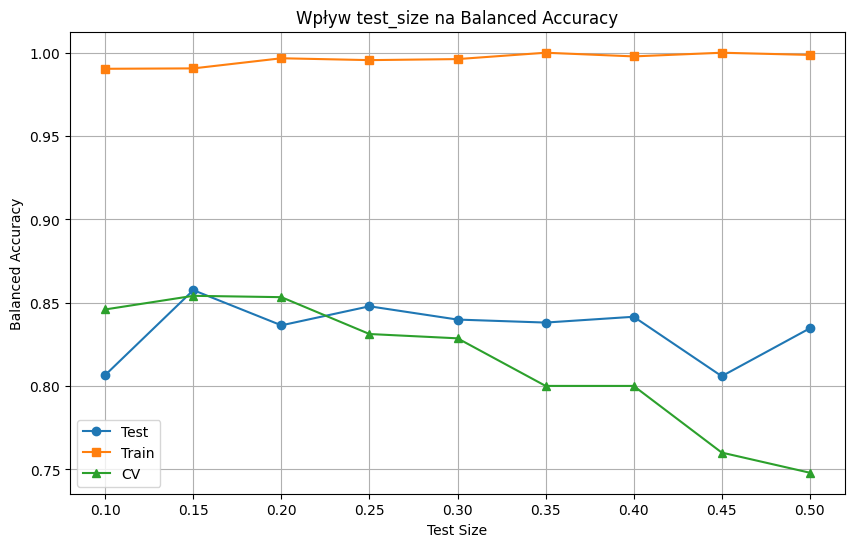

In [76]:
wykres_w_zal_od_ts(test_sizes, pipeline_xgb_balanced_4)

In [79]:
pipeline_xgb_balanced_5 = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,       
            learning_rate=0.06,      
            max_depth=6,
            subsample=0.85,                  
            min_samples_split=5,
            min_samples_leaf=3,    
            random_state=42, 
            max_features='sqrt'
        ),
        threshold='1.2*mean'
    )),
    ('classifier', XGBClassifier( 
            eval_metric='logloss', 
            n_estimators=315,  # obnizam z 320
            learning_rate=0.06, 
            max_depth=5,        
            subsample=0.87,        # podwyzszam z 0.85
            colsample_bytree=0.87,  # podwyzszam z 0.85  
            min_child_weight=3,
            reg_alpha=0.3,         
            reg_lambda=4,
            gamma=0.3,             # podwyzszam z 0.2      
            random_state=42))])

In [119]:
with parallel_backend("threading"):
    pipeline_xgb_balanced_5.fit(X_train, y_train)
scoring_v2(pipeline_xgb_balanced_5, "xgb_balanced_5")

BA test: 0.85762
BA train: 0.99058


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


CV mean: 0.84635
CV std: 0.01379


UWAGA: spadlo accuracy mean na cv i urosło std!

In [7]:
pipeline_xgb_balanced_6 = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,       
            learning_rate=0.06,      
            max_depth=6,
            subsample=0.85,                  
            min_samples_split=5,
            min_samples_leaf=3,    
            random_state=42, 
            max_features='sqrt'
        ),
        threshold='1.2*mean'
    )),
    ('classifier', XGBClassifier( 
            eval_metric='logloss', 
            n_estimators=330,  
            learning_rate=0.06, # obniam bo podwyzszylam n_estimators
            max_depth=5,        
            subsample=0.9,      #  podwyzszam z 0.87
            colsample_bytree=0.75,   # obniam z 0.87
            min_child_weight=3,
            reg_alpha=0.3,         
            reg_lambda=5,
            gamma=0.2,                 
            random_state=42))])

In [247]:
with parallel_backend("threading"):
    pipeline_xgb_balanced_6.fit(X_train, y_train)
scoring_v2(pipeline_xgb_balanced_6, "xgb_balanced_6")

BA test: 0.84869
BA train: 0.99059
CV mean: 0.85969
CV std: 0.01317


In [131]:
pipeline_xgb_balanced_7 = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,       
            learning_rate=0.06,      
            max_depth=6,
            subsample=0.85,     #             
            min_samples_split=5,
            min_samples_leaf=3,    
            random_state=42, 
            max_features='sqrt'
        ),
        threshold='1.2*mean' #
    )),
    ('classifier', XGBClassifier( 
            eval_metric='logloss', 
            n_estimators=600,  
            learning_rate=0.03, 
            max_depth=5,        
            subsample=0.9,      
            colsample_bytree=0.75,   
            min_child_weight=3,
            reg_alpha=0.3,         
            reg_lambda=4,
            gamma=0.2,                 
            random_state=42))])

In [132]:
with parallel_backend("threading"):
    pipeline_xgb_balanced_7.fit(X_train, y_train)
scoring_v2(pipeline_xgb_balanced_7, "xgb_balanced_7")

BA test: 0.84430
BA train: 0.98822
CV mean: 0.86127
CV std: 0.01144


LGBM FINE TUNING - LESS OVERFITTING
===============================

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, balanced_accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

pipeline_lgbm_1 = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,
            learning_rate=0.06, 
            max_depth=6,
            subsample=0.85,
            min_samples_split=5,
            min_samples_leaf=3, 
            max_features='sqrt',
            random_state=42
        ),
        threshold='1.2*mean'
    )),
    ('classifier', LGBMClassifier(
        n_estimators=320,       # zmniejszam z 500
        learning_rate=0.06,     # zmniejszam z 0.07
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,      
        num_leaves=40,
        min_child_samples=5,        
        reg_alpha=0.1,              #  L1 regularization
        reg_lambda=1.0,             #  L2 regularization
        random_state=42, 
        verbose=0 ))
])

In [ ]:
with parallel_backend("threading"):
    pipeline_lgbm_1.fit(X_train, y_train) # za duzo n_estimators w LGBMClassifier
scoring_v2(pipeline_lgbm_1, "lgbm_1")

In [6]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
pipeline_lgbm_2 = Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,
            learning_rate=0.06, 
            max_depth=6,
            subsample=0.85,
            min_samples_split=5,
            min_samples_leaf=3, 
            max_features='sqrt',
            random_state=42
        ),
        threshold='1.2*mean'
    )),
    ('classifier', LGBMClassifier(
        n_estimators=140,           # zmniejszam z 320 (warningi zaczynają się później)
        learning_rate=0.063,
        max_depth=-1,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_samples=10,
        min_split_gain=0.01,
        reg_alpha=0.3,
        reg_lambda=2.0,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])

In [168]:
with parallel_backend("threading"):
    pipeline_lgbm_2.fit(X_train, y_train)
scoring_v2(pipeline_lgbm_2, "lgbm_2")

BA test: 0.85762
BA train: 0.99844
CV mean: 0.85891
CV std: 0.01564


VOTING
======================

Zrobię jeszcze VotingClassifier z gb, lgbm i xgb

In [171]:
from sklearn.ensemble import VotingClassifier

voting_00 = VotingClassifier(
    estimators=[
        ('lgbm', pipeline_lgbm_2),
        ('xgb', pipeline_xgb_balanced_4),
        ('gb', Pipeline([
            ('scaler', RobustScaler()),
            ('selector', SelectFromModel(
                RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42),
                threshold='1.2*mean'
            )),
            ('classifier', GradientBoostingClassifier(
                n_estimators=300, learning_rate=0.05, max_depth=5,
                subsample=0.75, min_samples_split=12, min_samples_leaf=6,
                random_state=42
            ))
        ]))
    ],
    voting='soft',
    weights=[2,2,1]
)

In [172]:
with parallel_backend("threading", n_jobs=-1):
    voting_00.fit(X_train,y_train)

scoring_v2(voting_00,'voting 00')

BA test: 0.87089
BA train: 0.99765
CV mean: 0.86123
CV std: 0.01537


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

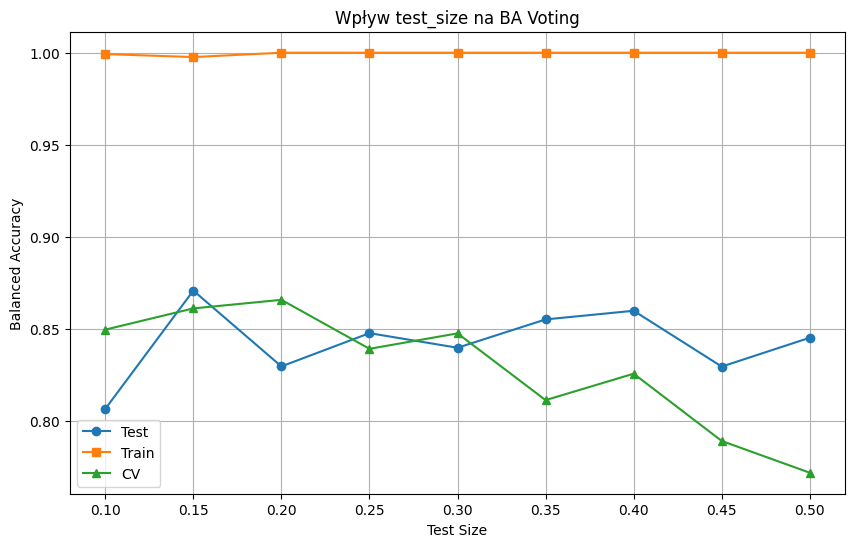

In [216]:
test_sizes = sorted([0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], reverse=True)

wykres_w_zal_od_ts(test_sizes, voting_00,"Voting")

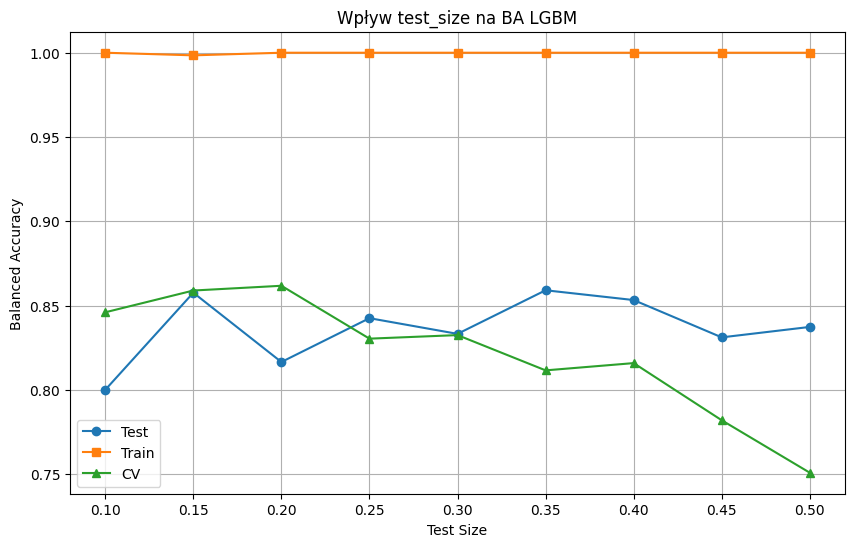

In [217]:
wykres_w_zal_od_ts(test_sizes, pipeline_lgbm_2,"LGBM")

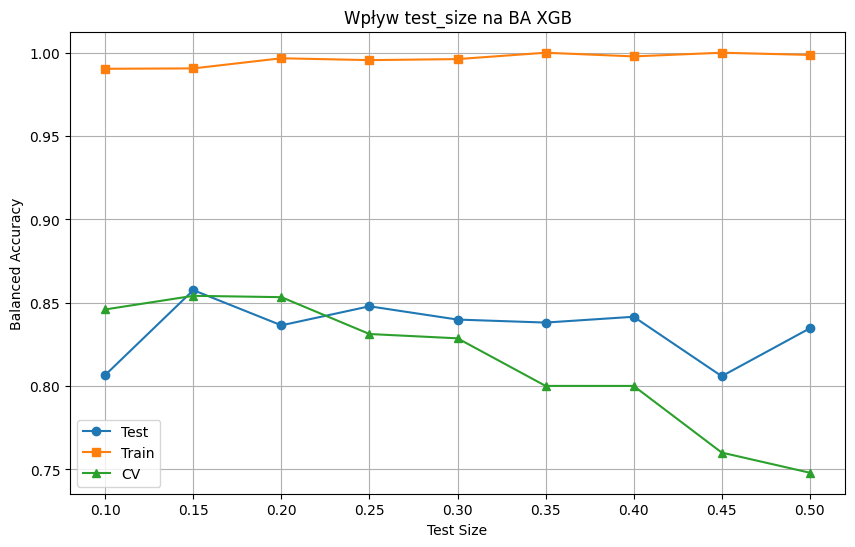

In [218]:
wykres_w_zal_od_ts(test_sizes, pipeline_xgb_balanced_4,"XGB")

In [7]:
from sklearn.ensemble import VotingClassifier

voting_11 = VotingClassifier(
    estimators=[
        ('lgbm', pipeline_lgbm_2),
        ('xgb 4', pipeline_xgb_balanced_4),
        ('xgb 3', pipeline_xgb_balanced_3)
    ],
    voting='soft',
    weights=[2,2,1]
)

In [14]:
with parallel_backend("threading", n_jobs=-1):
    voting_11.fit(X_train,y_train)

scoring_v2(voting_11,'voting 11')

NameError: name 'X_train' is not defined

/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

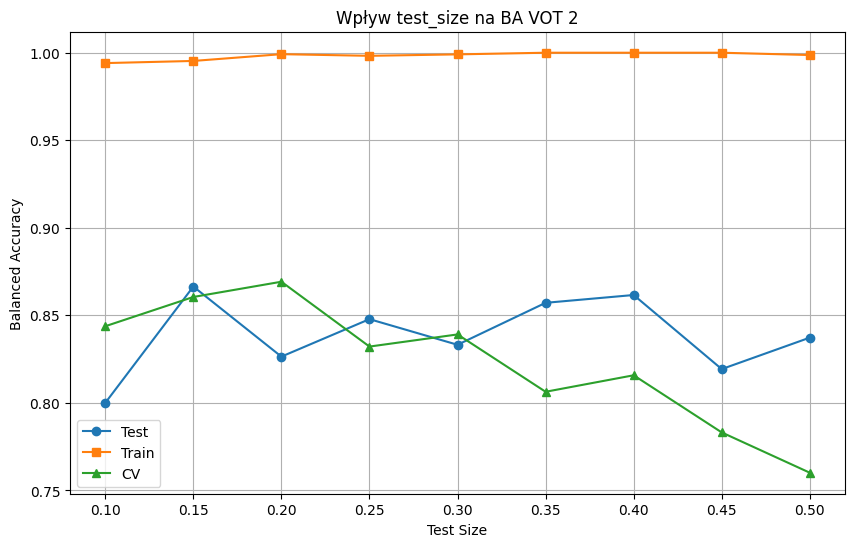

In [233]:
wykres_w_zal_od_ts(test_sizes, voting_11,"VOT 2")

In [229]:
voting_22 = VotingClassifier(
    estimators=[
        ('lgbm', pipeline_lgbm_2),
        ('xgb 4', pipeline_xgb_balanced_4),
        ('xgb 7', pipeline_xgb_balanced_7)
    ],
    voting='soft',
    weights=[1,2,2]
)
with parallel_backend("threading", n_jobs=-1):
    voting_22.fit(X_train,y_train)

scoring_v2(voting_22,'voting 22')

BA test: 0.86200
BA train: 0.99216


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

CV mean: 0.86129
CV std: 0.01121


In [231]:
voting_33 = VotingClassifier(
    estimators=[
        ('lgbm', pipeline_lgbm_2),
        ('xgb 4', pipeline_xgb_balanced_4),
        ('xgb 7', Pipeline([
    ('scaler', RobustScaler()),  
    ('selector', SelectFromModel(
        GradientBoostingClassifier(
            n_estimators=400,       
            learning_rate=0.06,      
            max_depth=6,
            subsample=0.85,                  
            min_samples_split=5,
            min_samples_leaf=3,    
            random_state=42, 
            max_features='sqrt'
        ),
        threshold='1.2*mean' 
    )),
    ('classifier', XGBClassifier( 
            eval_metric='logloss', 
            n_estimators=500,  
            learning_rate=0.03, 
            max_depth=5,        
            subsample=0.9,      
            colsample_bytree=0.75,   
            min_child_weight=3,
            reg_alpha=0.3,         
            reg_lambda=4,
            gamma=0.2,                 
            random_state=42))]))
    ],
    voting='soft',
    weights=[1,2,2]
)
with parallel_backend("threading", n_jobs=-1):
    voting_33.fit(X_train,y_train)

scoring_v2(voting_33,'voting 33')





BA test: 0.85758
BA train: 0.98979


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

CV mean: 0.86129
CV std: 0.01121


In [253]:
voting_44 = VotingClassifier(
    estimators=[
        ('lgbm', pipeline_lgbm_2),
        ('xgb 7', pipeline_xgb_balanced_7),
        ('xgb 4', pipeline_xgb_balanced_4),
        ('xgb 6', pipeline_xgb_balanced_6)
    ],
    voting='soft',
    weights=[1,2,2,3]
)
with parallel_backend("threading", n_jobs=-1):
    voting_44.fit(X_train,y_train)

scoring_v2(voting_44,'voting 44')

BA test: 0.85311
BA train: 0.99294


/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/wiktoriagrodzka/anaconda3/lib/python3.11/site-packages/pandas/cor

CV mean: 0.86206
CV std: 0.01291


In [8]:
with parallel_backend("threading", n_jobs=-1):
    voting_11.fit(cechy_train,etykiety_train)

In [9]:
probabilities = voting_11.predict_proba(cechy_test)

In [10]:
prob=probabilities[:,1]
prob

array([0.01628496, 0.92093675, 0.34789284, 0.84149161, 0.7698938 ,
       0.94232372, 0.01211805, 0.17030902, 0.24171584, 0.9602936 ,
       0.87363978, 0.95748332, 0.3817786 , 0.09401819, 0.95799364,
       0.49741997, 0.84478049, 0.10110706, 0.97487861, 0.97175951,
       0.03937522, 0.20313397, 0.09741292, 0.51901899, 0.08379099,
       0.20865889, 0.06106005, 0.96485519, 0.64130474, 0.96086257,
       0.46351736, 0.93801737, 0.97753383, 0.85208331, 0.90960541,
       0.8817198 , 0.10489195, 0.43326809, 0.96160618, 0.35644202,
       0.0395884 , 0.98805828, 0.16537677, 0.08045413, 0.06376619,
       0.8912542 , 0.00737247, 0.40085352, 0.99055835, 0.42219285,
       0.21809294, 0.16188569, 0.95921301, 0.91227797, 0.11798224,
       0.02211984, 0.04078682, 0.82783037, 0.16922035, 0.13671146,
       0.58923795, 0.87705474, 0.79664169, 0.07342955, 0.01801295,
       0.81069313, 0.1003552 , 0.03702669, 0.04332446, 0.19361636,
       0.12866941, 0.9637158 , 0.55796007, 0.69579291, 0.34347